# 0. Librairies

In [ ]:
from utils import *
from ddpm import *

# 1. Datasets

## 1.1. Load data

In [ ]:
dataset_repertory = '/home/johnny/Diffusion model - Generation of turbulence time series/datasets/'
dataset_name = 'Lagr_u1c_diffusion-demo.h5'
normalized = False

velocities = load_data(dataset_repertory, dataset_name, normalized=False)
velocities.shape

(768, 1, 2000)

In [ ]:
# PARAMETERS
training_size = 0.8
validation_size = 0.1
normalization = True

# Split into training, validation and test sets and normalize them
velocities = th.tensor(velocities)
train, validation, test = training_test_split(velocities, training_size=0.8, validation_size=0.1, normalization=True)
print(f"train shape : {train.shape} | validation shape : {validation.shape} | test shape : {test.shape}")

train shape : torch.Size([614, 1, 2000]) | validation shape : torch.Size([76, 1, 2000]) | test shape : torch.Size([78, 1, 2000])


## 1.2. Data Analysis

### 1.2.1. Time-series

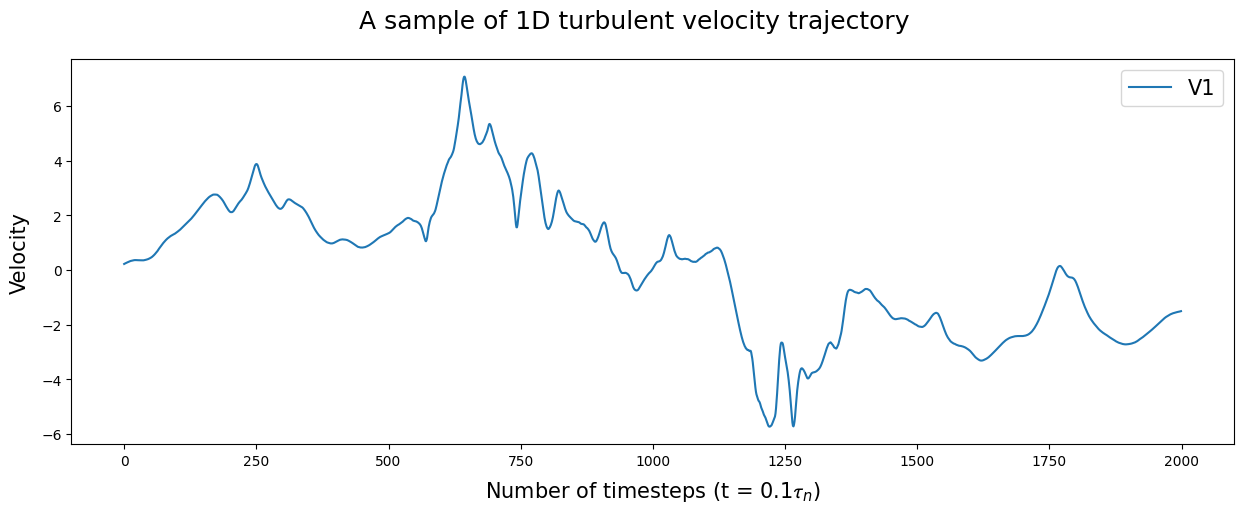

In [10]:
plot_time_series(velocities[10])

### 1.2.2. Probability density function (PDF) of velocity increments

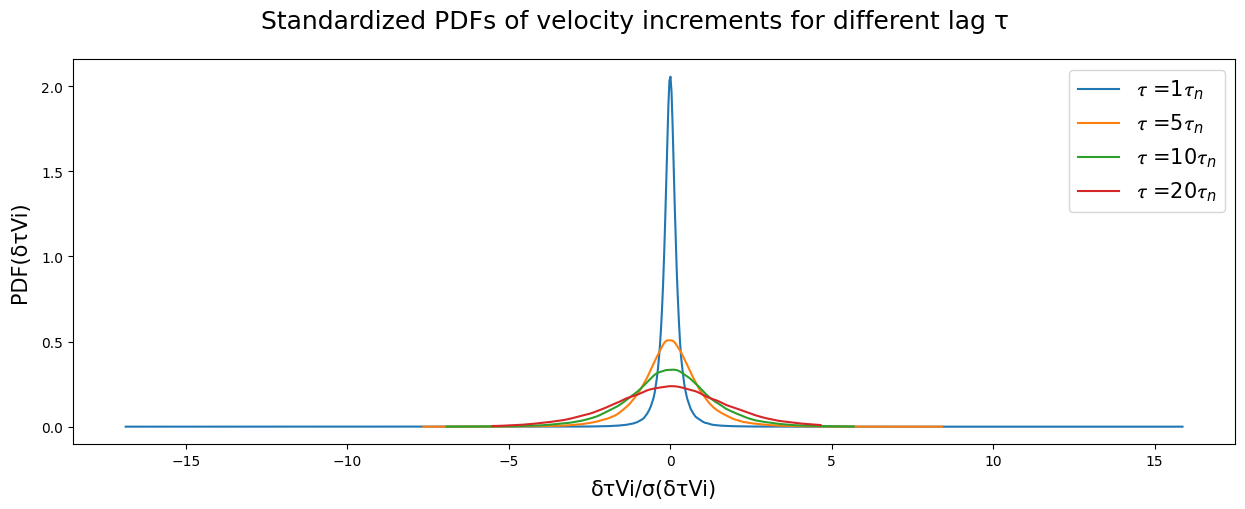

In [9]:
tau_values = [10,50,100,200]
plot_pdf_increments(velocities, tau_values)

### 1.2.3. Lagrangian structure function and flatness

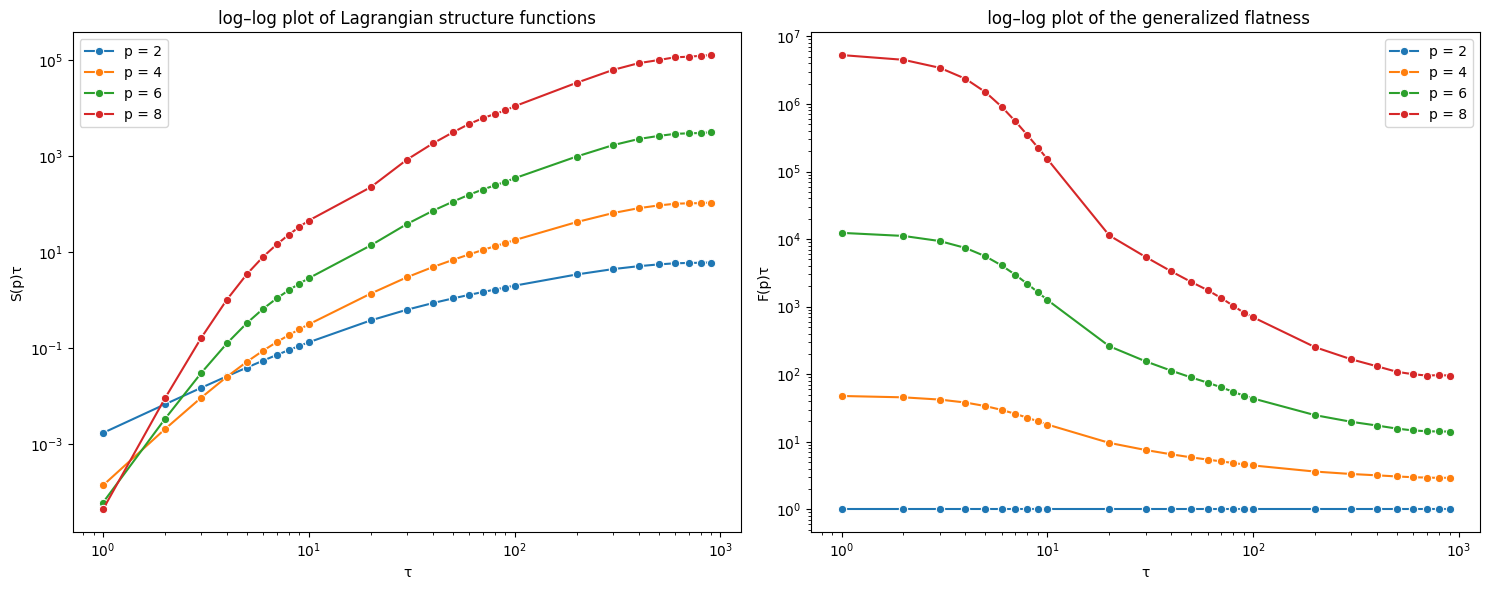

In [8]:
tau_values = [i * 10**j for j in range(3) for i in range(1,10)]
p_values = [2,4,6,8]

plot_structure_flatness(velocities, p_values, tau_values)

# 2. Forward Process

## 2.1. Variance schedulers

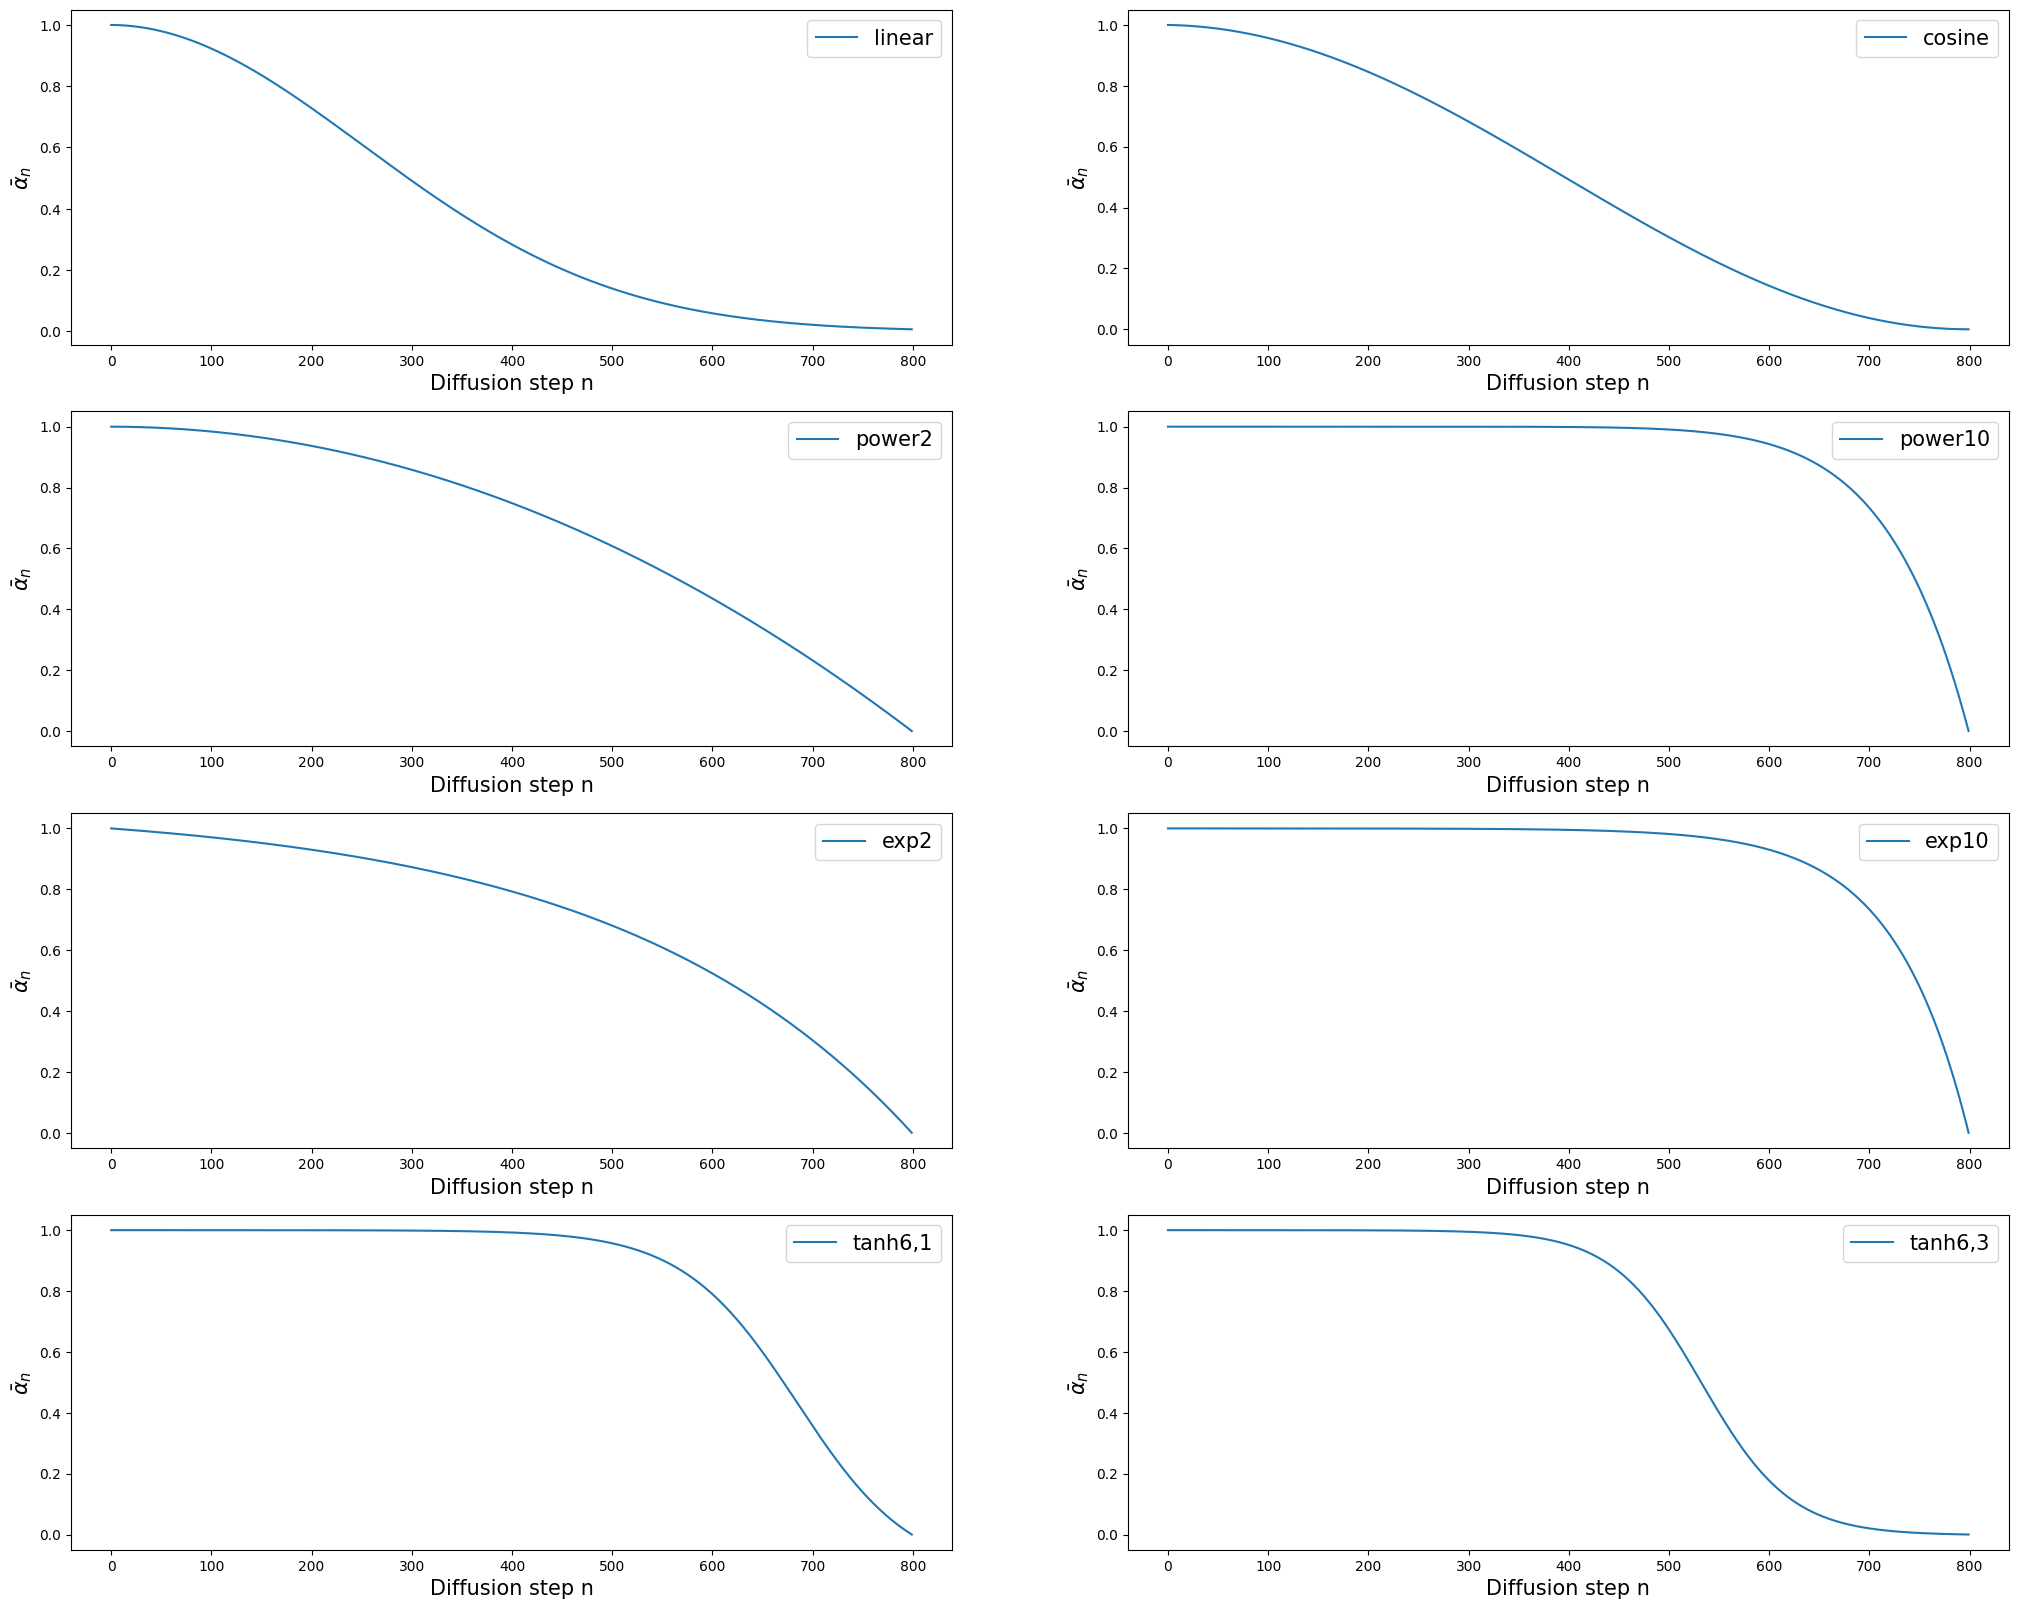

In [ ]:
# Number of diffusion steps
N = 800
# Noise schedules
noise_schedules = ['linear', 'cosine', 'power2', 'power10', 'exp2', 'exp10', 'tanh6,1', 'tanh6,3']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(25,20))
axes = axes.flatten()
for (i,schedule) in enumerate(noise_schedules):
    betas = get_named_beta_schedule(schedule, N)
    alpha_bar = np.cumprod(1-betas, axis=0)
    sns.lineplot(x = np.arange(N),
                 y = alpha_bar,
                 ax = axes[i],
                 label = schedule)
    axes[i].set_xlabel('Diffusion step n', fontsize=15)
    axes[i].set_ylabel(r'$\bar{\alpha}_n$', fontsize=15)
    axes[i].tick_params('x', labelsize=10)
    axes[i].tick_params('y', labelsize=10)
    axes[i].legend(fontsize=15)

## 2.2. Adding noise to time series

IndexError: too many indices for tensor of dimension 1

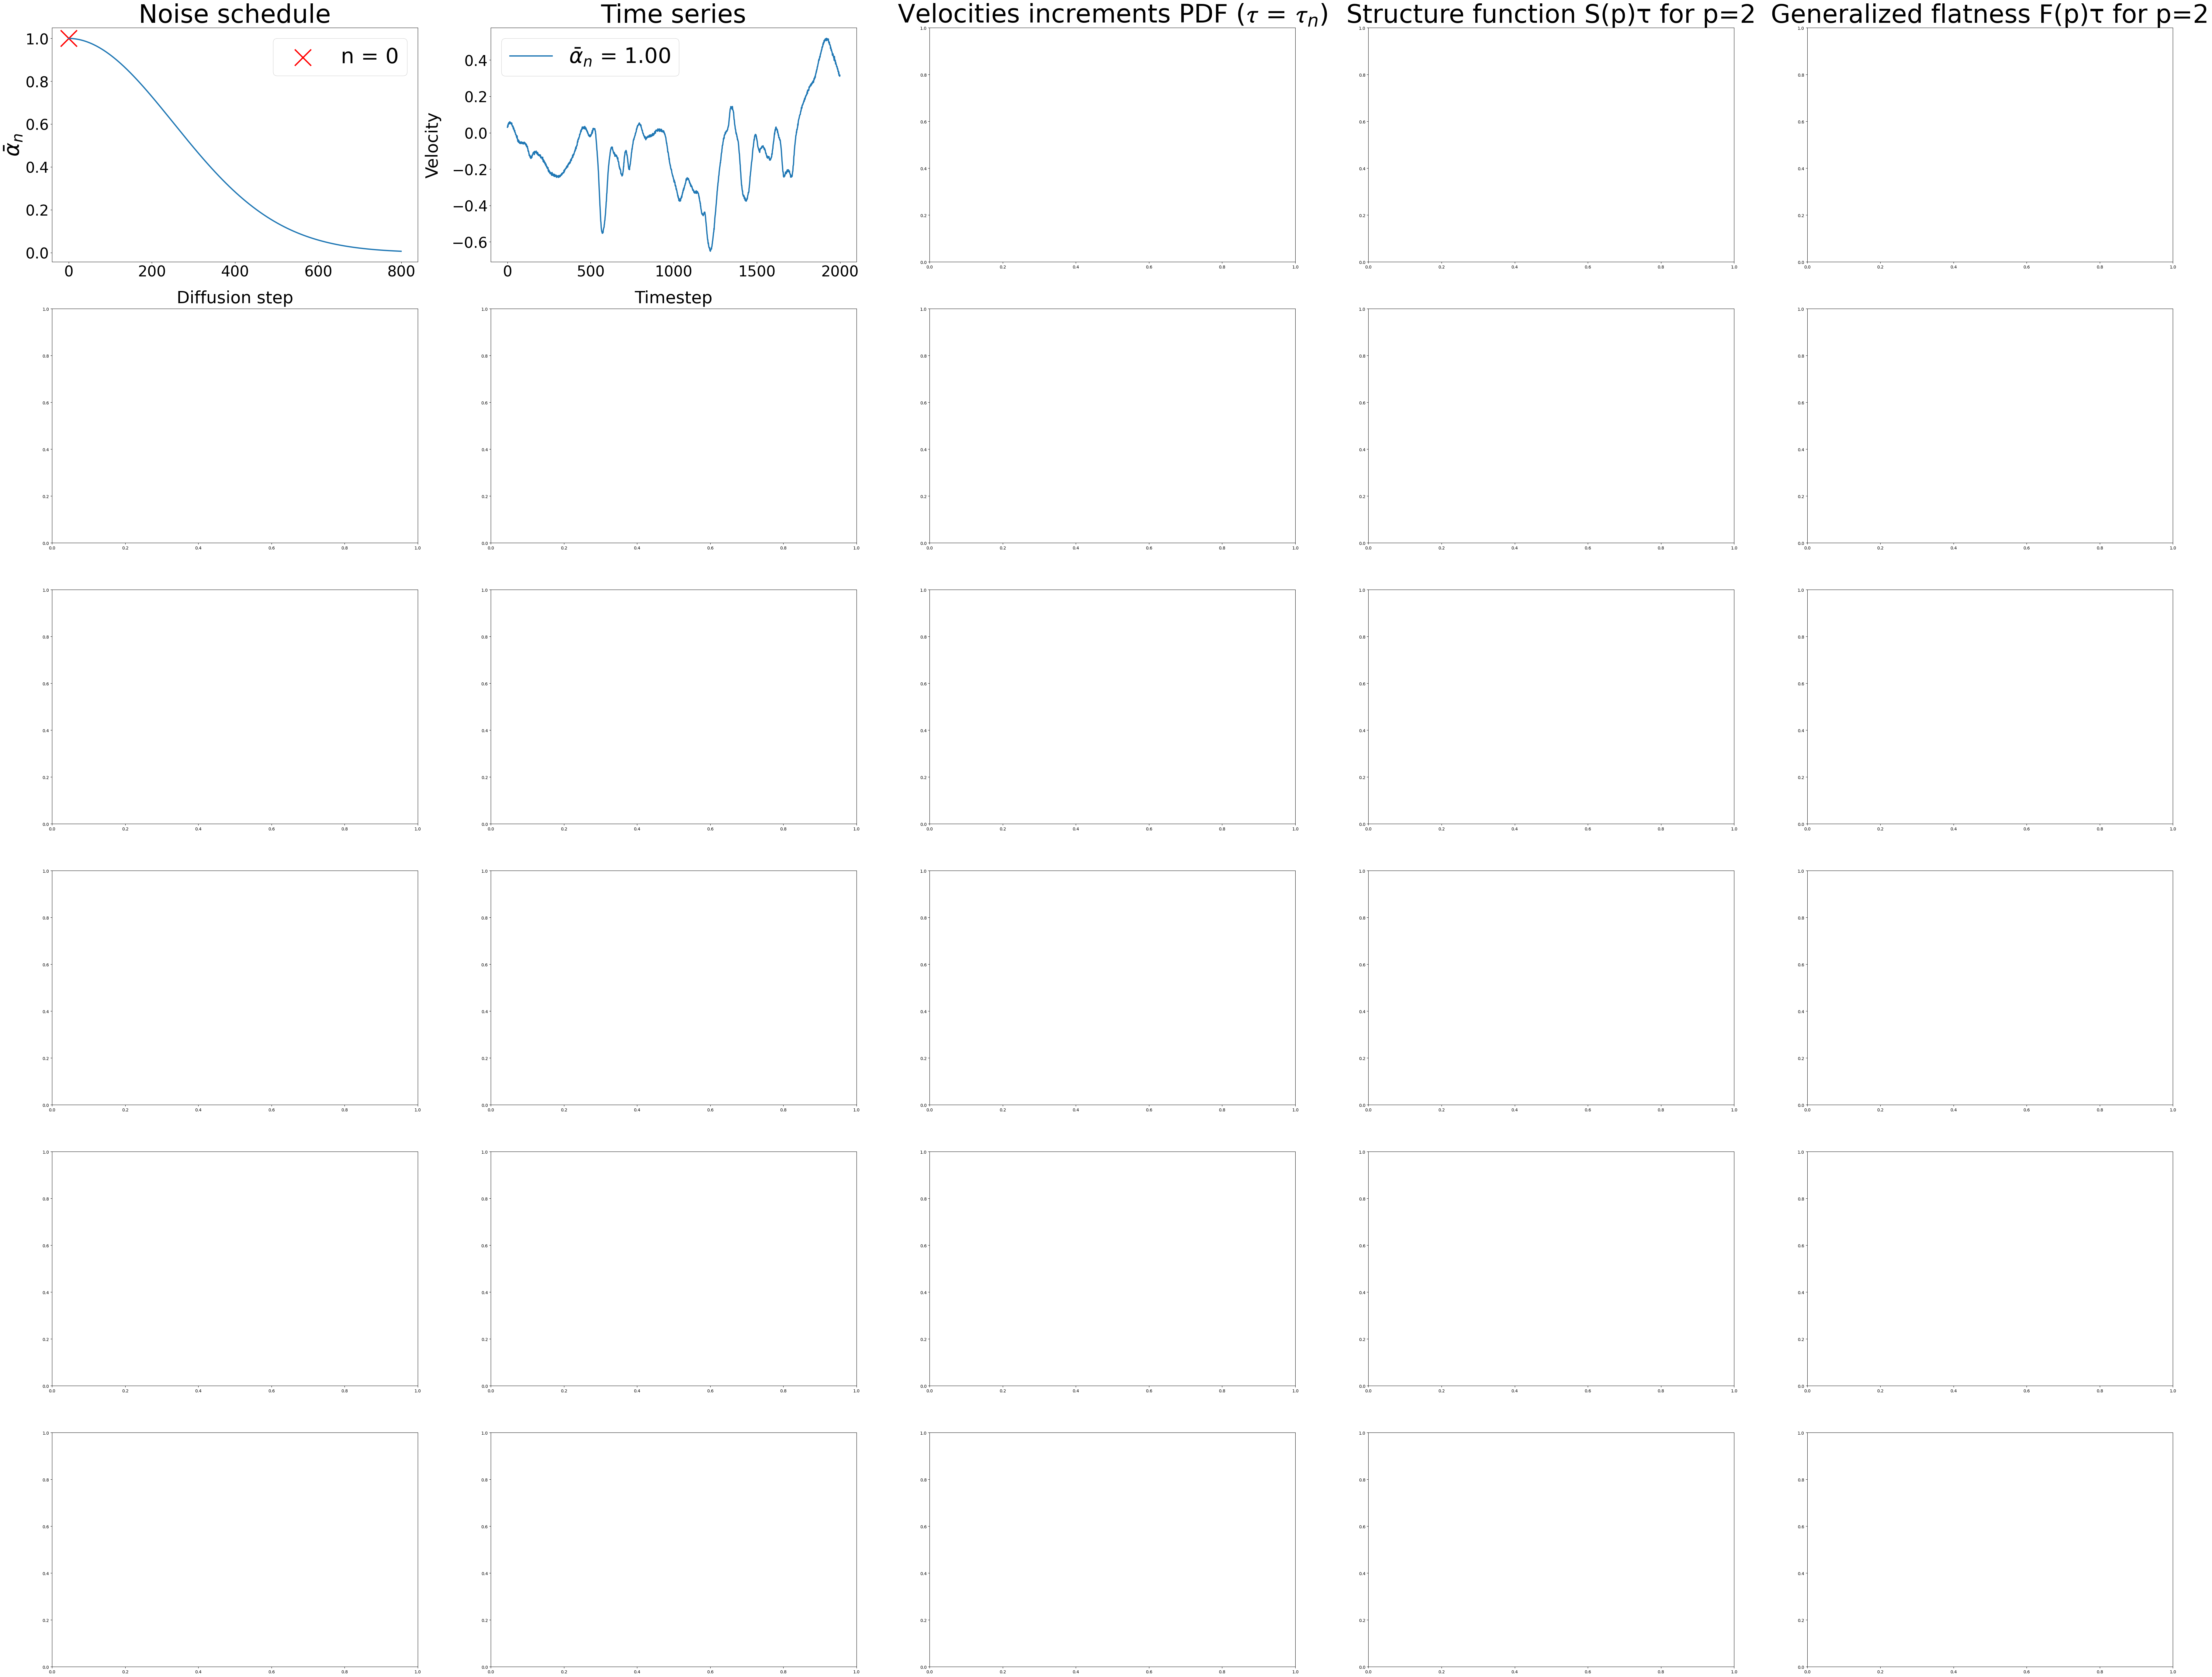

In [ ]:
V0 = test
N = 800
schedule_name = 'linear'
diffusion_steps_ratio = [0,0.1,0.25,0.5,0.75,1]

plot_forward(V0=V0, num_diffusion_steps=N, schedule_name=schedule_name, diffusion_steps_ratio=diffusion_steps_ratio)